In [3]:
import os
import shutil
import zipfile
import pandas as pd
from google.colab import files

# Путь к исходному файлу
source_path = '/content/kaggle.json'  # или другой путь, где находится файл
destination_dir = '/root/.kaggle'
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    # Устанавливаем права доступа
    os.chmod(destination_path, 0o600)
else:
    # Загружаем файл, если его нет
    uploaded = files.upload()
    # После загрузки переместите файл в нужную директорию
    if 'kaggle.json' in uploaded:
        shutil.move('kaggle.json', destination_path)
        os.chmod(destination_path, 0o600)

# Теперь можно использовать Kaggle API для загрузки датасета
!kaggle datasets download -d harlfoxem/housesalesprediction



Dataset URL: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
License(s): CC0-1.0
  0% 0.00/780k [00:00<?, ?B/s]
100% 780k/780k [00:00<00:00, 1.01GB/s]


In [4]:
# Распакуйте скачанный архив:
with zipfile.ZipFile('housesalesprediction.zip', 'r') as zip_ref:
    zip_ref.extractall('housesalesprediction')

 # Показать файлы в директории
print("Файлы в директории:")
print(os.listdir('housesalesprediction'))


df = pd.read_csv('housesalesprediction/kc_house_data.csv')

# Просматриваем первые несколько строк датасета
print("\nПервые 5 строк датасета:")
print(df.head())

# Получаем общую информацию о датасете
print("\nИнформация о датасете:")
print(df.info())

# Выводим статистические данные о числовых столбцах
print("\nСтатистическое описание:")
print(df.describe())


Файлы в директории:
['kc_house_data.csv']

Первые 5 строк датасета:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 50)
print(f"Размер датасета: {df.shape}")
print(f"\nКолонки:\n{df.columns.tolist()}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nСтатистика по числовым признакам:")
print(df.describe())
print(f"\nПропущенные значения:")
print(df.isnull().sum())

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер датасета: (21613, 21)

Колонки:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Типы данных:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Первые 5 строк:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0     

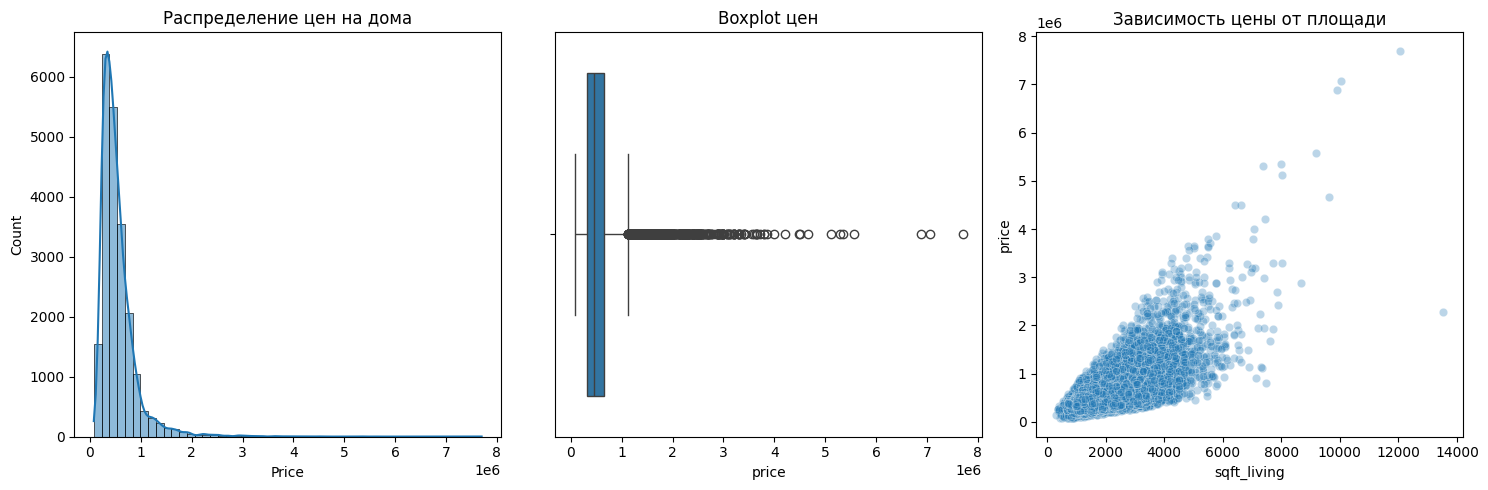

Размер обучающей выборки: (17290, 21)
Размер тестовой выборки: (4323, 21)


In [8]:
# Анализ целевой переменной (price)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
# и другие модули, которые используете


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Распределение цен на дома')
plt.xlabel('Price')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['price'])
plt.title('Boxplot цен')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.3)
plt.title('Зависимость цены от площади')

plt.tight_layout()
plt.show()

# Подготовка признаков
# Удаляем ненужные колонки и обрабатываем дату
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df = df.drop('date', axis=1)

# Отделяем целевую переменную
X = df.drop('price', axis=1)
y = df['price']

# Логарифмируем целевую переменную (часто помогает для цен на недвижимость)
y_log = np.log1p(y)

# Разделяем на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Масштабируем признаки (для некоторых регрессоров это важно)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00
CATBOOST РЕГРЕССОР (только числовые признаки)
Используем 21 числовых признаков
Подбор параметров для CatBoost с GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры CatBoost: {'regressor__border_count': 128, 'regressor__depth': 6, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 1, 'regressor__learning_rate': 0.1}

Результаты для CatBoost:
Лучшие параметры: {'regressor__border_count': 128, 'regressor__depth': 6, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 1, 'regressor__learning_rate': 0.1}
Лучшая MSE на кросс-валидации: 0.03
MSE на тесте: 0.02
MAE на тесте: 0.11
R2 на тесте: 0.9127


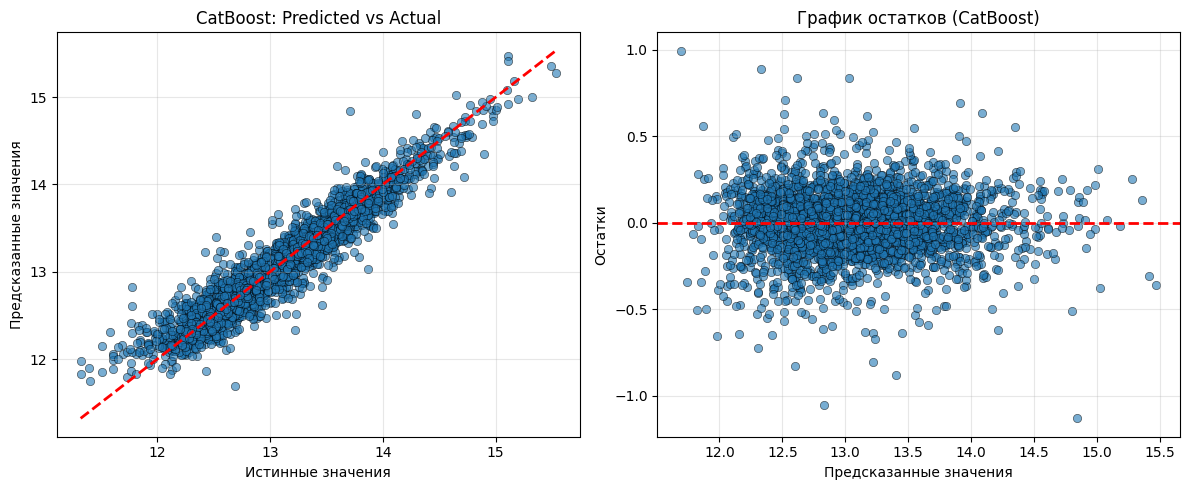

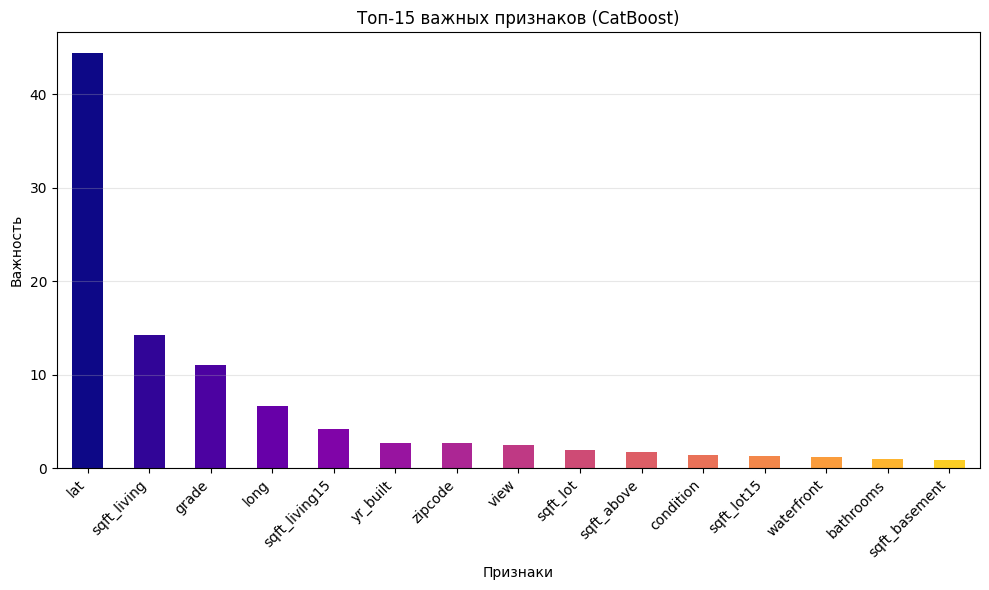

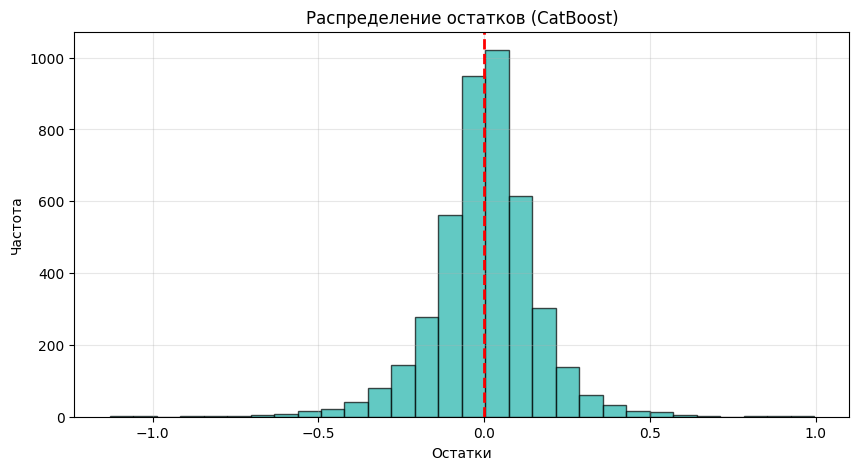

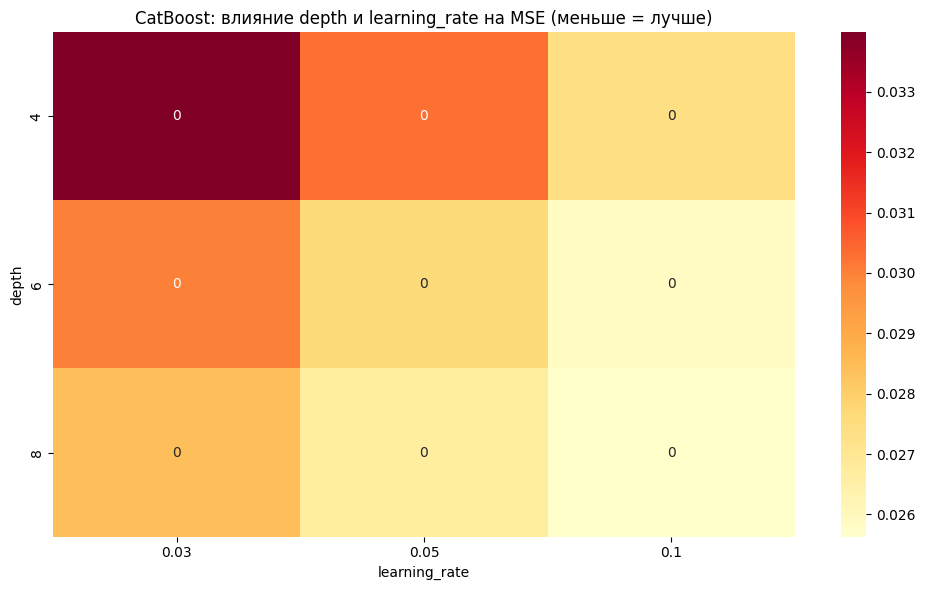


 Топ-5 лучших комбинаций параметров CatBoost:
  {'regressor__border_count': 128, 'regressor__depth': 6, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 1, 'regressor__learning_rate': 0.1} | MSE: 0 ± 0
  {'regressor__border_count': 255, 'regressor__depth': 8, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 1, 'regressor__learning_rate': 0.1} | MSE: 0 ± 0
  {'regressor__border_count': 255, 'regressor__depth': 8, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 3, 'regressor__learning_rate': 0.1} | MSE: 0 ± 0
  {'regressor__border_count': 255, 'regressor__depth': 6, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 1, 'regressor__learning_rate': 0.1} | MSE: 0 ± 0
  {'regressor__border_count': 255, 'regressor__depth': 6, 'regressor__iterations': 500, 'regressor__l2_leaf_reg': 3, 'regressor__learning_rate': 0.1} | MSE: 0 ± 0


In [10]:
# 1. CatBoost (только числовые признаки)
!pip install catboost
from catboost import CatBoostRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=" * 60)
print("CATBOOST РЕГРЕССОР (только числовые признаки)")
print("=" * 60)

# Используем ВСЕ признаки из X_train как числовые
# (предполагаем, что X_train уже загружен и все признаки числовые)
numeric_features = X_train.columns.tolist()
print(f"Используем {len(numeric_features)} числовых признаков")

# Создаем простой препроцессор (только для совместимости, ничего не меняем)
preprocessor_cb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features)  # все признаки оставляем как есть
    ])

# Пайплайн с препроцессором и CatBoost
cb_pipeline = Pipeline(steps=[('preprocessor', preprocessor_cb),
                              ('regressor', CatBoostRegressor(random_state=42, verbose=0))])

# Сетка параметров для GridSearchCV
param_grid_cb = {
    'regressor__iterations': [200, 500],           # количество деревьев
    'regressor__depth': [4, 6, 8],                  # глубина деревьев
    'regressor__learning_rate': [0.03, 0.05, 0.1],  # скорость обучения
    'regressor__l2_leaf_reg': [1, 3, 5],            # L2 регуляризация
    'regressor__border_count': [128, 255]           # количество границ для дискретизации
}

# GridSearchCV с 5-кратной кросс-валидацией
grid_cb = GridSearchCV(cb_pipeline, param_grid_cb, cv=5,
                       scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print('Подбор параметров для CatBoost с GridSearchCV...')
grid_cb.fit(X_train, y_train)

print(f"Лучшие параметры CatBoost: {grid_cb.best_params_}")
best_cb = grid_cb.best_estimator_

# Функция evaluate_model
def evaluate_model(grid_search, X_train, y_train, X_test, y_test, model_name):
    """Оценивает модель и выводит метрики"""
    print(f"\nРезультаты для {model_name}:")
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучшая MSE на кросс-валидации: {-grid_search.best_score_:.2f}")

    # Предсказание на тестовой выборке
    y_pred = grid_search.predict(X_test)

    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MSE на тесте: {mse:.2f}")
    print(f"MAE на тесте: {mae:.2f}")
    print(f"R2 на тесте: {r2:.4f}")

    return y_pred

# Оценка модели и получение предсказаний
y_pred_cb = evaluate_model(grid_cb, X_train, y_train, X_test, y_test, "CatBoost")

# Визуализация
plt.figure(figsize=(12, 5))

# Predicted vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_cb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('CatBoost: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_cb = y_test - y_pred_cb
plt.scatter(y_pred_cb, residuals_cb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (CatBoost)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
feature_names = numeric_features
importances = best_cb.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 0.9, min(15, len(feat_imp))))
feat_imp.head(15).plot(kind='bar', color=colors)
plt.title('Топ-15 важных признаков (CatBoost)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_cb, bins=30, edgecolor='black', alpha=0.7, color='lightseagreen')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (CatBoost)')
plt.grid(True, alpha=0.3)
plt.show()

# Тепловая карта для визуализации влияния параметров
if hasattr(grid_cb, 'cv_results_'):
    results_cb = pd.DataFrame(grid_cb.cv_results_)

    # Создаём сводную таблицу для heatmap (глубина vs learning_rate)
    pivot_table_cb = results_cb.pivot_table(
        values='mean_test_score',
        index='param_regressor__depth',
        columns='param_regressor__learning_rate',
        aggfunc='mean'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(-pivot_table_cb, annot=True, fmt='.0f', cmap='YlOrRd',
                xticklabels=pivot_table_cb.columns, yticklabels=pivot_table_cb.index)
    plt.title('CatBoost: влияние depth и learning_rate на MSE (меньше = лучше)')
    plt.xlabel('learning_rate')
    plt.ylabel('depth')
    plt.tight_layout()
    plt.show()

# Сравнение top-5 лучших комбинаций
if hasattr(grid_cb, 'cv_results_'):
    top_results_cb = results_cb.nlargest(5, 'mean_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\n Топ-5 лучших комбинаций параметров CatBoost:")
    for i, row in top_results_cb.iterrows():
        print(f"  {row['params']} | MSE: {-row['mean_test_score']:.0f} ± {row['std_test_score']:.0f}")


GRADIENT BOOSTING РЕГРЕССОР
Размер обучающей выборки: (17290, 21)
Размер целевой переменной: (17290,)
✅ Данные загружены успешно!
Используем 21 числовых признаков

Всего комбинаций: 2×2×2×2×2 = 32 комбинации
С cv=5 будет: 32×5 = 160 обучений (~5-8 минут)

Подбор параметров для GradientBoosting с GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Лучшие параметры GradientBoosting: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}

Результаты для GradientBoosting:
Лучшие параметры: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}
Лучшая MSE на кросс-валидации: 0.03
MSE на тесте: 0.03
MAE на тесте: 0.12
R2 на тесте: 0.9078


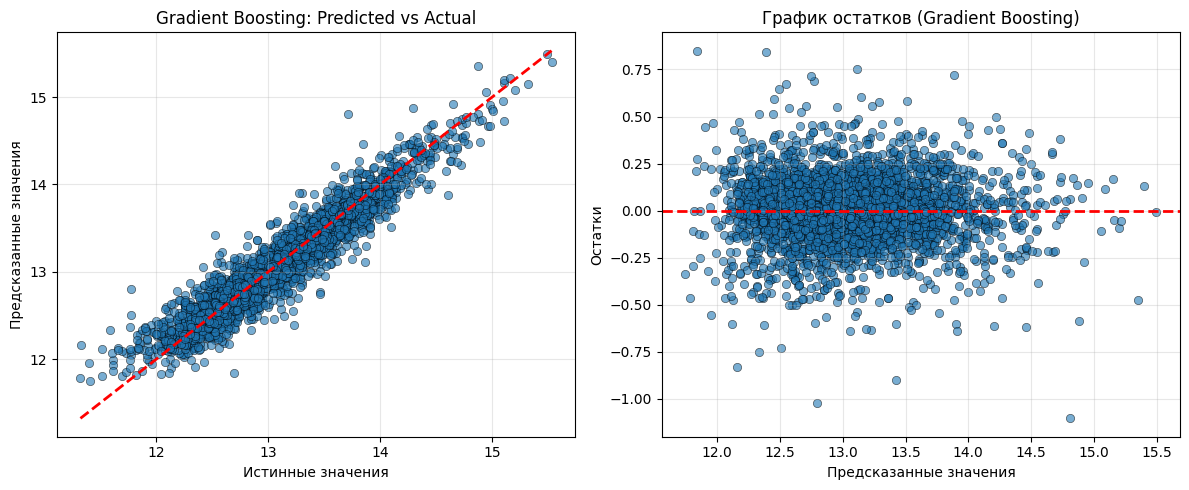

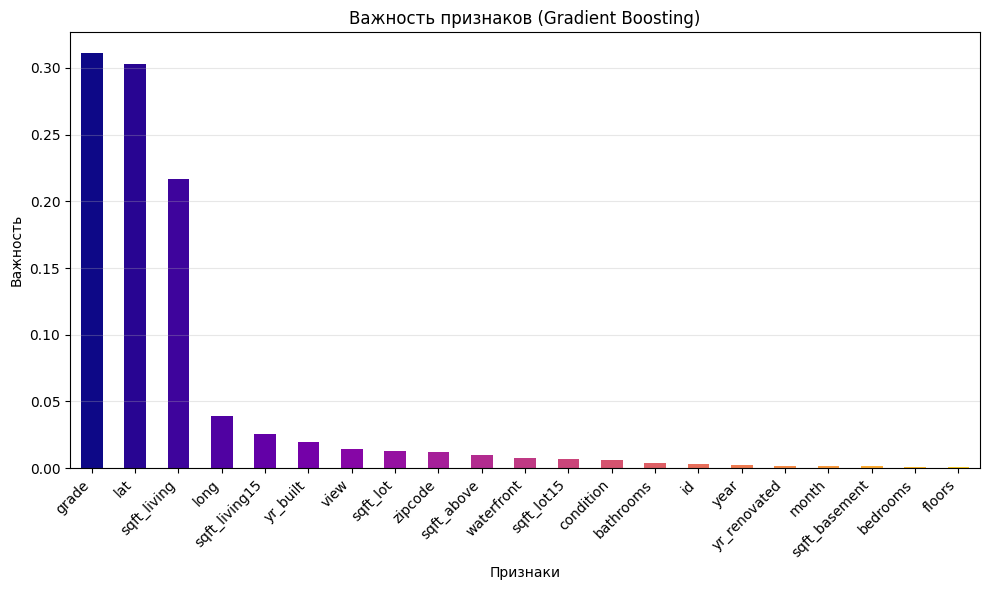

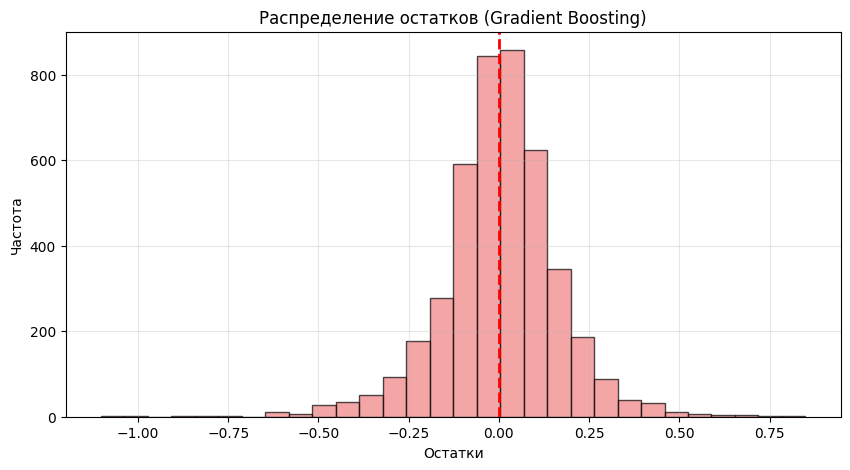

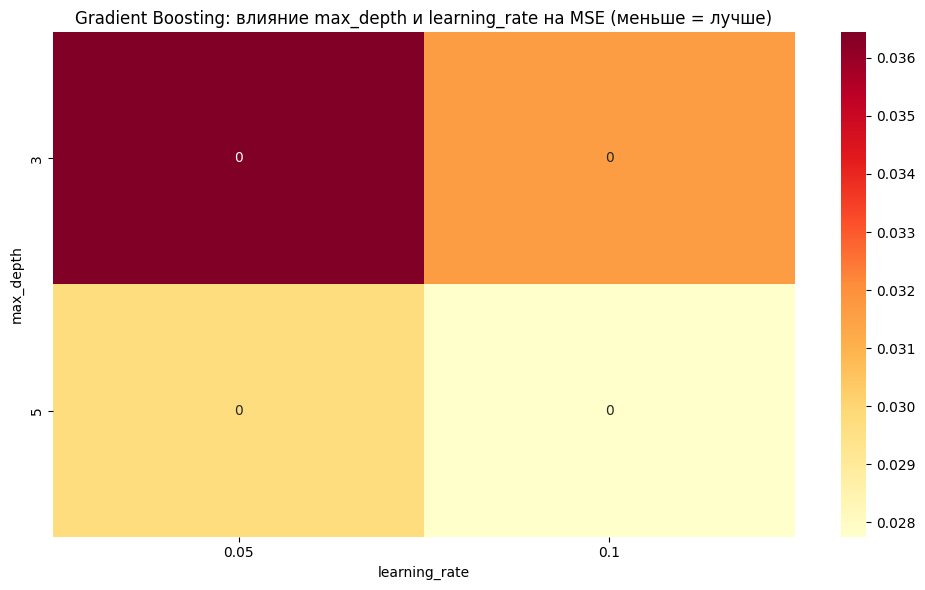

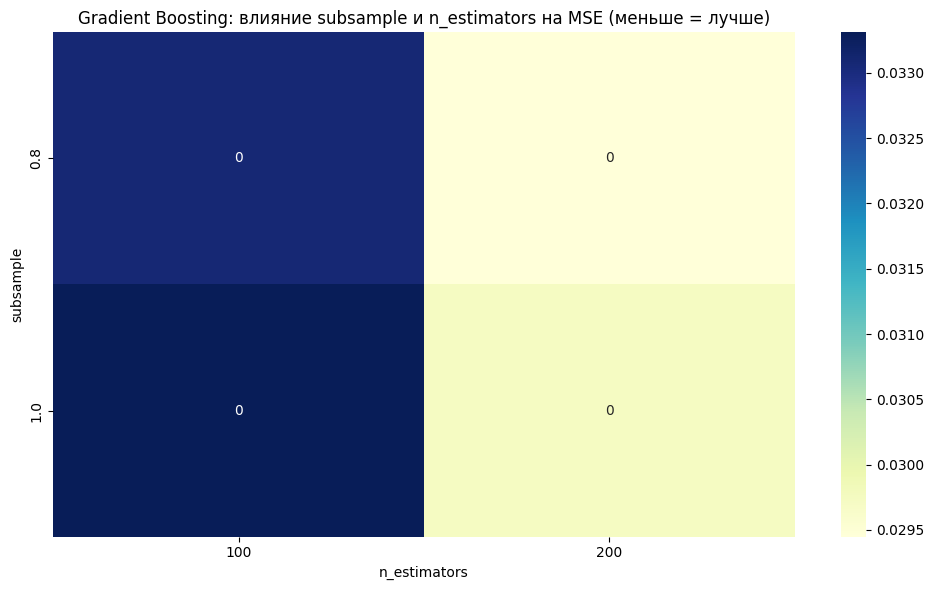


🔝 Топ-5 лучших комбинаций параметров Gradient Boosting:
  {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8} | MSE: 0 ± 0
  {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8} | MSE: 0 ± 0
  {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200, 'regressor__subsample': 1.0} | MSE: 0 ± 0
  {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 1.0} | MSE: 0 ± 0
  {'regressor__learning_rate': 0.05, 'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8} | MSE: 0 ± 0


In [11]:

# 2. Градиентный бустинг (GradientBoosting)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*60)
print("GRADIENT BOOSTING РЕГРЕССОР")
print("="*60)

# ПРОВЕРКА: определены ли X_train и y_train?
try:
    print(f"Размер обучающей выборки: {X_train.shape}")
    print(f"Размер целевой переменной: {y_train.shape}")
    print("✅ Данные загружены успешно!")
except NameError:
    print("❌ ОШИБКА: X_train и y_train не определены!")
    print("Пожалуйста, сначала выполните все предыдущие ячейки")
    raise SystemExit("Остановка выполнения")

# Определяем числовые признаки
numeric_features = X_train.columns.tolist()
print(f"Используем {len(numeric_features)} числовых признаков")

# Функция evaluate_model
def evaluate_model(grid_search, X_train, y_train, X_test, y_test, model_name):
    """Оценивает модель и выводит метрики"""
    print(f"\nРезультаты для {model_name}:")
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучшая MSE на кросс-валидации: {-grid_search.best_score_:.2f}")

    # Предсказание на тестовой выборке
    y_pred = grid_search.predict(X_test)

    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MSE на тесте: {mse:.2f}")
    print(f"MAE на тесте: {mae:.2f}")
    print(f"R2 на тесте: {r2:.4f}")

    return y_pred

# Создаем препроцессор
preprocessor_gb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features)
    ])

# Пайплайн с препроцессором и градиентным бустингом
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor_gb),
                               ('regressor', GradientBoostingRegressor(random_state=42))])

# Сетка параметров
param_grid_gb = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__min_samples_split': [2, 5]
}

print(f"\nВсего комбинаций: 2×2×2×2×2 = 32 комбинации")
print(f"С cv=5 будет: 32×5 = 160 обучений (~5-8 минут)")

# GridSearchCV
grid_gb = GridSearchCV(gb_pipeline, param_grid_gb, cv=5,
                       scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print('\nПодбор параметров для GradientBoosting с GridSearchCV...')
grid_gb.fit(X_train, y_train)

print(f"\n✅ Лучшие параметры GradientBoosting: {grid_gb.best_params_}")
best_gb = grid_gb.best_estimator_

# Оценка модели
y_pred_gb = evaluate_model(grid_gb, X_train, y_train, X_test, y_test, "GradientBoosting")

# ВИЗУАЛИЗАЦИЯ
# Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_gb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Gradient Boosting: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_gb = y_test - y_pred_gb
plt.scatter(y_pred_gb, residuals_gb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (Gradient Boosting)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
importances = best_gb.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=numeric_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 0.9, len(feat_imp)))
feat_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (Gradient Boosting)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_gb, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (Gradient Boosting)')
plt.grid(True, alpha=0.3)
plt.show()

# Тепловая карта: глубина vs learning_rate
results_gb = pd.DataFrame(grid_gb.cv_results_)
pivot_table_gb = results_gb.pivot_table(
    values='mean_test_score',
    index='param_regressor__max_depth',
    columns='param_regressor__learning_rate',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(-pivot_table_gb, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=pivot_table_gb.columns, yticklabels=pivot_table_gb.index)
plt.title('Gradient Boosting: влияние max_depth и learning_rate на MSE (меньше = лучше)')
plt.xlabel('learning_rate')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

# Тепловая карта: subsample vs n_estimators
pivot_subsample_gb = results_gb.pivot_table(
    values='mean_test_score',
    index='param_regressor__subsample',
    columns='param_regressor__n_estimators',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(-pivot_subsample_gb, annot=True, fmt='.0f', cmap='YlGnBu',
            xticklabels=pivot_subsample_gb.columns, yticklabels=pivot_subsample_gb.index)
plt.title('Gradient Boosting: влияние subsample и n_estimators на MSE (меньше = лучше)')
plt.xlabel('n_estimators')
plt.ylabel('subsample')
plt.tight_layout()
plt.show()

# Топ-5 лучших комбинаций
top_results_gb = results_gb.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score']
]
print("\n🔝 Топ-5 лучших комбинаций параметров Gradient Boosting:")
for i, row in top_results_gb.iterrows():
    print(f"  {row['params']} | MSE: {-row['mean_test_score']:.0f} ± {row['std_test_score']:.0f}")




RANDOM FOREST РЕГРЕССОР
Всего комбинаций: 2×3×2×2 = 24 комбинации
С cv=5 будет: 24×5 = 120 обучений
⏱ Примерное время: 4-6 минут
Подбор параметров для RandomForest с GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Лучшие параметры RandomForest: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}

Результаты для RandomForest:
Лучшие параметры: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Лучшая MSE на кросс-валидации: 0.03
MSE на тесте: 0.03
MAE на тесте: 0.13
R2 на тесте: 0.8906


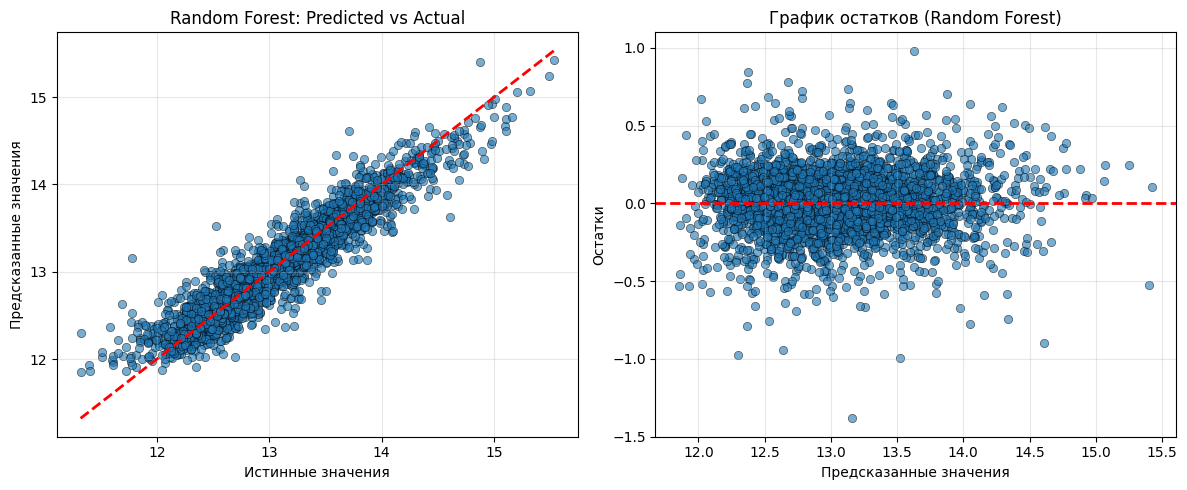

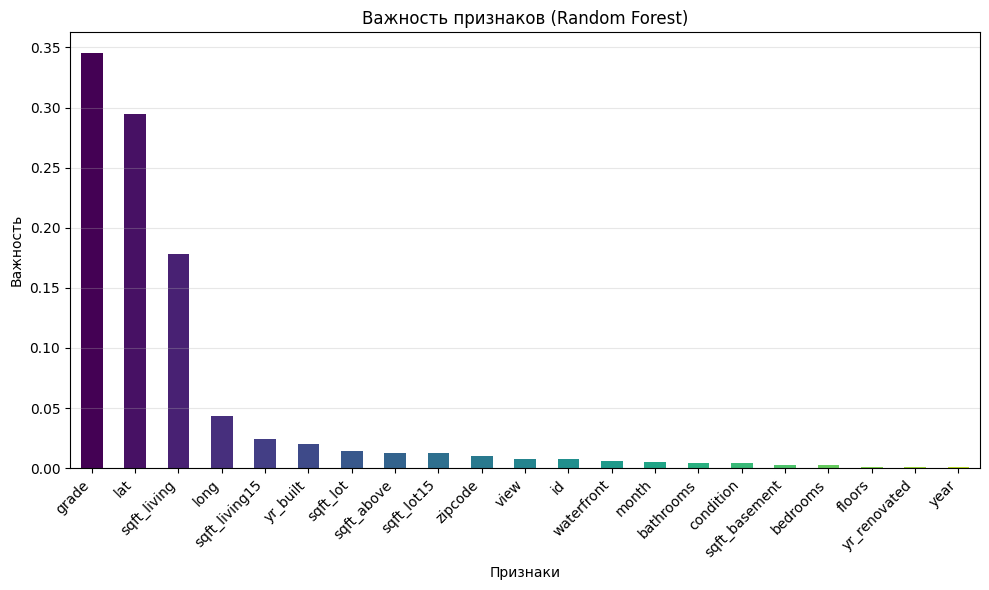

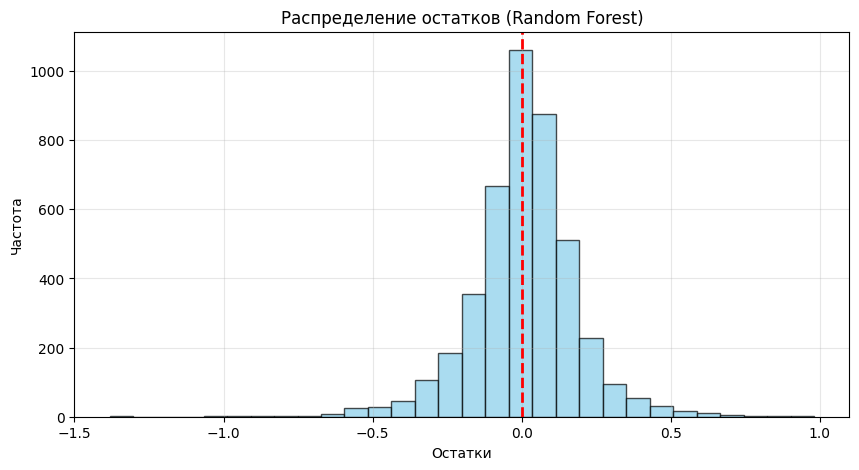


🔝 Топ-5 лучших комбинаций параметров Random Forest:
  {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200} | MSE: 0 ± 0
  {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200} | MSE: 0 ± 0
  {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200} | MSE: 0 ± 0
  {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200} | MSE: 0 ± 0
  {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200} | MSE: 0 ± 0


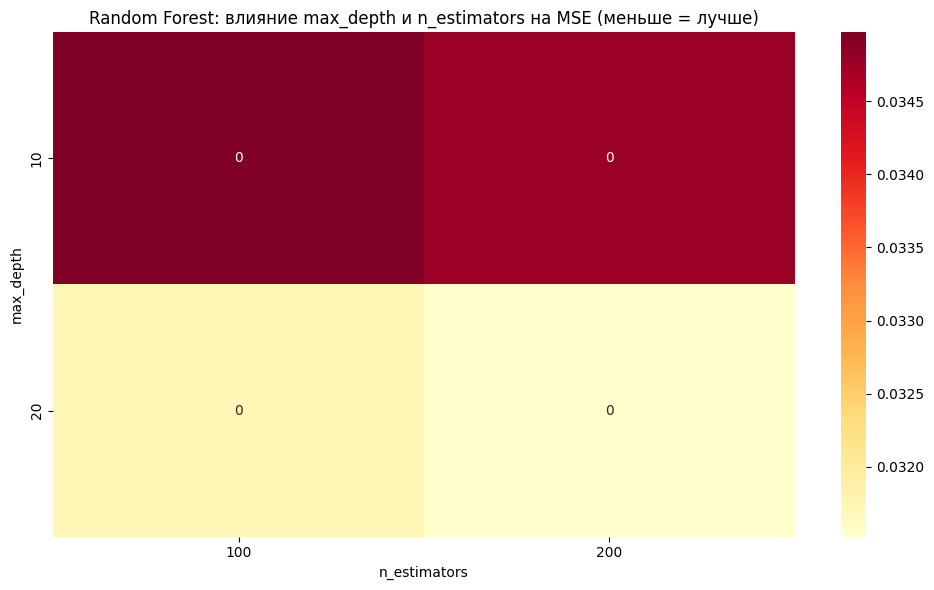

In [12]:
# 3. Случайный лес (RandomForest)
from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*60)
print("RANDOM FOREST РЕГРЕССОР")
print("="*60)

# Для случайного леса предобработка не обязательна.
# Создадим пайплайн только с числовыми признаками
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features)  # только числовые признаки
    ])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor_rf),
                               ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])

# Сетка параметров для Случайного леса
param_grid_rf = {
    'regressor__n_estimators': [100, 200],        # количество деревьев
    'regressor__max_depth': [10, 20, None],       # максимальная глубина (None = без ограничений)
    'regressor__min_samples_split': [2, 5],        # мин. образцов для разделения узла
    'regressor__min_samples_leaf': [1, 2]          # мин. образцов в листе
}

print(f"Всего комбинаций: 2×3×2×2 = 24 комбинации")
print(f"С cv=5 будет: 24×5 = 120 обучений")
print(f"⏱ Примерное время: 4-6 минут")

# GridSearchCV с 5-кратной кросс-валидацией
grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5,
                       scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print('Подбор параметров для RandomForest с GridSearchCV...')
grid_rf.fit(X_train, y_train)

print(f"\n✅ Лучшие параметры RandomForest: {grid_rf.best_params_}")
best_rf = grid_rf.best_estimator_

# Оценка модели и получение предсказаний
y_pred_rf = evaluate_model(grid_rf, X_train, y_train, X_test, y_test, "RandomForest")

# Визуализация

# Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Random Forest: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_rf = y_test - y_pred_rf
plt.scatter(y_pred_rf, residuals_rf, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (Random Forest)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
# (только числовые признаки)
feature_names = numeric_features

importances = best_rf.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(feat_imp)))
feat_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_rf, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (Random Forest)')
plt.grid(True, alpha=0.3)
plt.show()

# Сравнение результатов GridSearch
results_rf = pd.DataFrame(grid_rf.cv_results_)
top_results = results_rf.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']].copy()
top_results['mean_test_score'] = -top_results['mean_test_score']
top_results = top_results.rename(columns={'mean_test_score': 'MSE'})

print("\n🔝 Топ-5 лучших комбинаций параметров Random Forest:")
for i, row in top_results.iterrows():
    print(f"  {row['params']} | MSE: {row['MSE']:.0f} ± {row['std_test_score']:.0f}")

# Дополнительно: тепловая карта для визуализации влияния параметров
if hasattr(grid_rf, 'cv_results_'):
    # Создаём сводную таблицу для heatmap (max_depth vs n_estimators)
    pivot_rf = results_rf.pivot_table(
        values='mean_test_score',
        index='param_regressor__max_depth',
        columns='param_regressor__n_estimators',
        aggfunc='mean'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(-pivot_rf, annot=True, fmt='.0f', cmap='YlOrRd',
                xticklabels=pivot_rf.columns, yticklabels=pivot_rf.index)
    plt.title('Random Forest: влияние max_depth и n_estimators на MSE (меньше = лучше)')
    plt.xlabel('n_estimators')
    plt.ylabel('max_depth')
    plt.tight_layout()
    plt.show()


XGBOOST РЕГРЕССОР
 Всего комбинаций: 1×2×2×1×1 = 8 комбинаций
 С cv=5 будет: 8×5 = 40 обучений
  Примерное время: 2-4 минуты
Подбор параметров для XGBoost с GridSearchCV...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

 Лучшие параметры XGBoost: {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__n_estimators': 150, 'regressor__subsample': 0.9}

Результаты для XGBoost:
Лучшие параметры: {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__n_estimators': 150, 'regressor__subsample': 0.9}
Лучшая MSE на кросс-валидации: 0.03
MSE на тесте: 0.03
MAE на тесте: 0.11
R2 на тесте: 0.9099


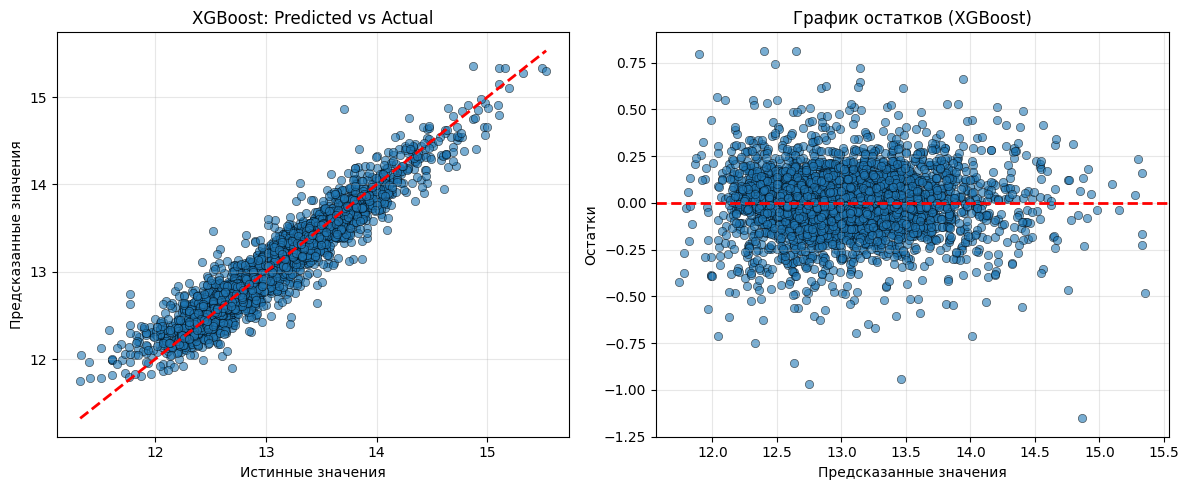

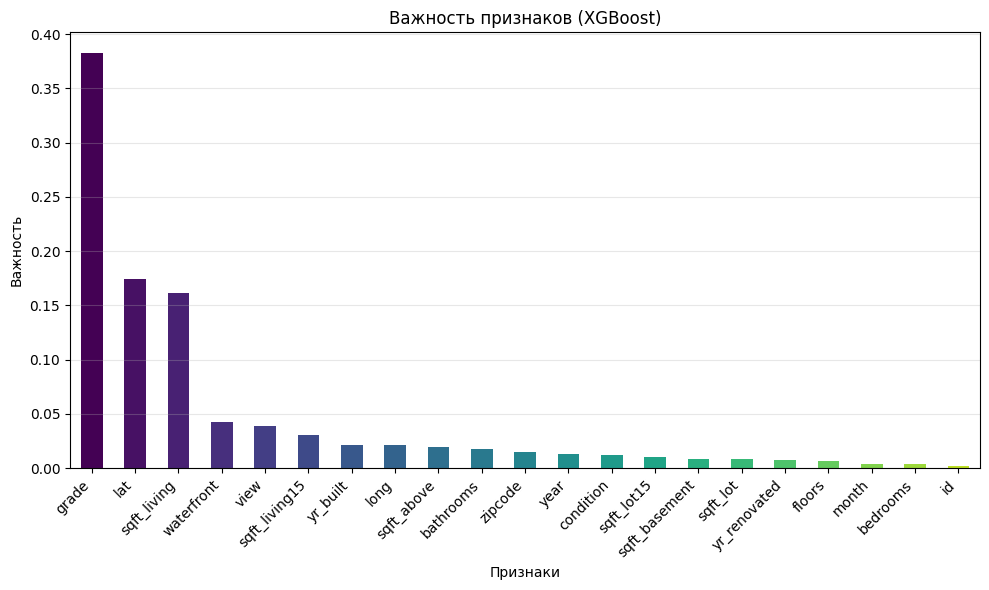

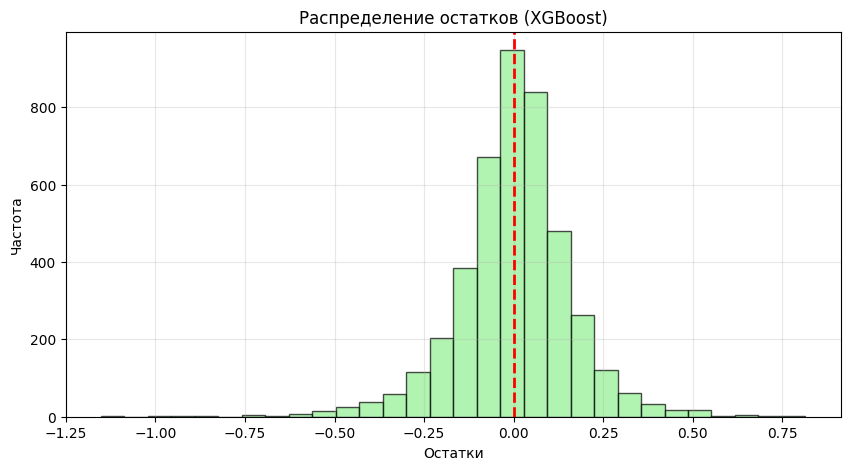

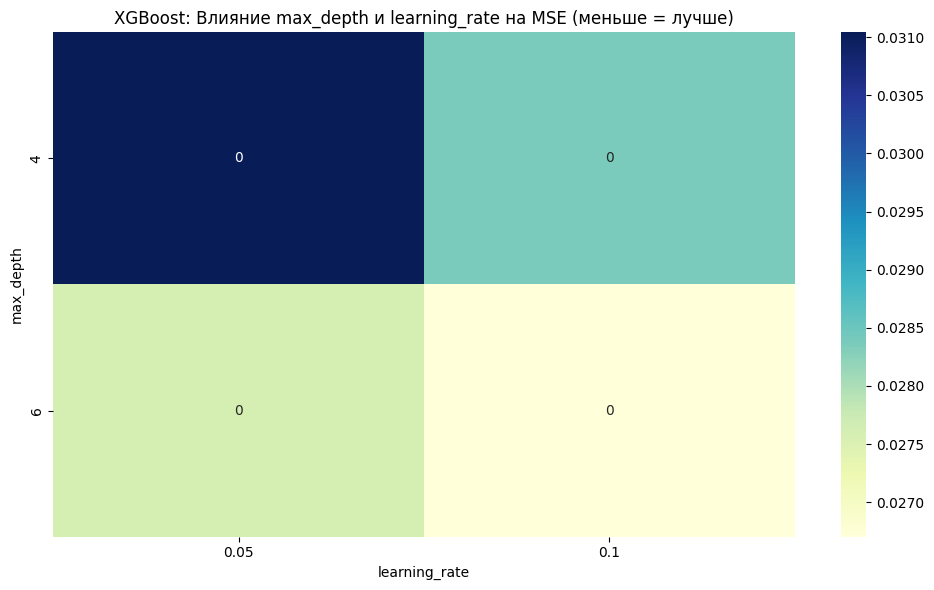


 Все комбинации параметров XGBoost (от лучшей к худшей):
  {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__n_estimators': 150, 'regressor__subsample': 0.9} | MSE: 0 ± 0
  {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 6, 'regressor__n_estimators': 150, 'regressor__subsample': 0.9} | MSE: 0 ± 0
  {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 4, 'regressor__n_estimators': 150, 'regressor__subsample': 0.9} | MSE: 0 ± 0
  {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 4, 'regressor__n_estimators': 150, 'regressor__subsample': 0.9} | MSE: 0 ± 0


In [13]:
# 4. XGBoost
import xgboost as xgb

print("\n" + "="*60)
print("XGBOOST РЕГРЕССОР")
print("="*60)

# Создаем препроцессор (только числовые признаки)
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features)
    ])

# Пайплайн с препроцессором и XGBoost
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor_xgb),
                                ('regressor', xgb.XGBRegressor(random_state=42, verbosity=0))])

# ОПТИМИЗИРОВАННАЯ сетка параметров (всего 8 комбинаций!)
param_grid_xgb = {
    'regressor__n_estimators': [150],              # фиксируем среднее значение
    'regressor__max_depth': [4, 6],                 # только 2 варианта
    'regressor__learning_rate': [0.05, 0.1],        # только 2 варианта
    'regressor__subsample': [0.9],                  # фиксируем
    'regressor__colsample_bytree': [0.9]            # фиксируем
}

print(f" Всего комбинаций: 1×2×2×1×1 = 8 комбинаций")
print(f" С cv=5 будет: 8×5 = 40 обучений")
print(f"  Примерное время: 2-4 минуты")

# GridSearchCV с 5-кратной кросс-валидацией
grid_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5,
                         scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

print('Подбор параметров для XGBoost с GridSearchCV...')
grid_xgb.fit(X_train, y_train)

print(f"\n Лучшие параметры XGBoost: {grid_xgb.best_params_}")
best_xgb = grid_xgb.best_estimator_

# Оценка модели и получение предсказаний
y_pred_xgb = evaluate_model(grid_xgb, X_train, y_train, X_test, y_test, "XGBoost")

# Визуализация
# Predicted vs Actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_xgb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('XGBoost: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_xgb = y_test - y_pred_xgb
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (XGBoost)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков
feature_names = numeric_features

importances = best_xgb.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(feat_imp)))
feat_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (XGBoost)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_xgb, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (XGBoost)')
plt.grid(True, alpha=0.3)
plt.show()

# Тепловая карта
if hasattr(grid_xgb, 'cv_results_'):
    results_xgb = pd.DataFrame(grid_xgb.cv_results_)

    # Создаём сводную таблицу для heatmap (max_depth vs learning_rate)
    pivot_lr_depth = results_xgb.pivot_table(
        values='mean_test_score',
        index='param_regressor__max_depth',
        columns='param_regressor__learning_rate',
        aggfunc='mean'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(-pivot_lr_depth, annot=True, fmt='.0f', cmap='YlGnBu',
                xticklabels=pivot_lr_depth.columns, yticklabels=pivot_lr_depth.index)
    plt.title('XGBoost: Влияние max_depth и learning_rate на MSE (меньше = лучше)')
    plt.xlabel('learning_rate')
    plt.ylabel('max_depth')
    plt.tight_layout()
    plt.show()

# Сравнение всех комбинаций (их всего 8)
if hasattr(grid_xgb, 'cv_results_'):
    results_xgb = pd.DataFrame(grid_xgb.cv_results_)
    all_results_xgb = results_xgb[['params', 'mean_test_score', 'std_test_score']].copy()
    all_results_xgb['mean_test_score'] = -all_results_xgb['mean_test_score']
    all_results_xgb = all_results_xgb.rename(columns={'mean_test_score': 'MSE'})
    all_results_xgb = all_results_xgb.sort_values('MSE')

    print("\n Все комбинации параметров XGBoost (от лучшей к худшей):")
    for i, row in all_results_xgb.iterrows():
        print(f"  {row['params']} | MSE: {row['MSE']:.0f} ± {row['std_test_score']:.0f}")


HUBER РЕГРЕССОР
Найдено 21 числовых признаков
Всего комбинаций: 3×3×1 = 9 комбинаций
С cv=5 будет: 9×5 = 45 обучений
⏱ Примерное время: 1-2 минуты
Подбор параметров для HuberRegressor с GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

 Лучшие параметры HuberRegressor: {'regressor__alpha': 0.01, 'regressor__epsilon': 1.75, 'regressor__max_iter': 1000}

Результаты для HuberRegressor:
Лучшие параметры: {'regressor__alpha': 0.01, 'regressor__epsilon': 1.75, 'regressor__max_iter': 1000}
MSE на тесте: 0.06
MAE на тесте: 0.19
R2 на тесте: 0.7723


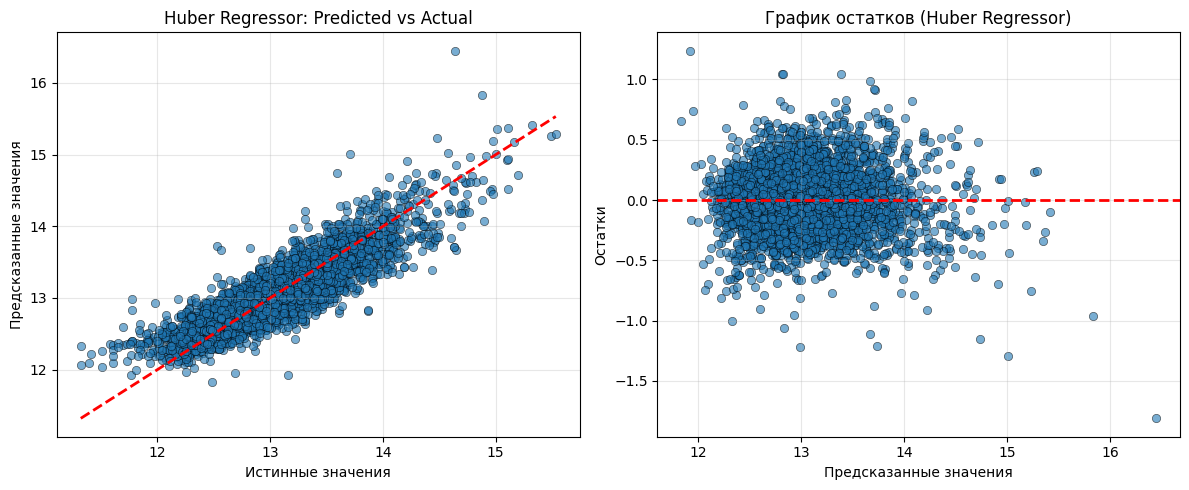

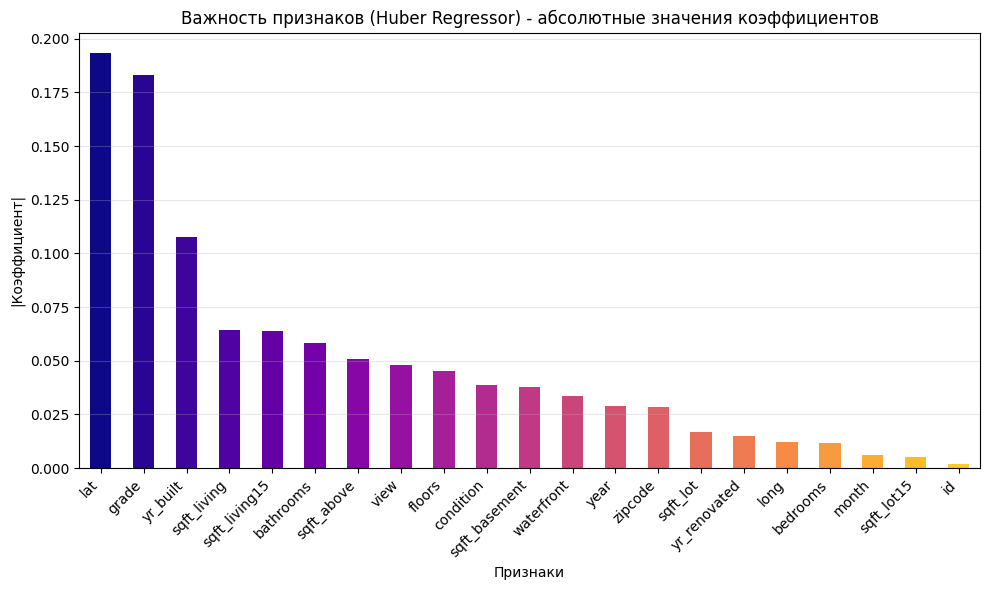

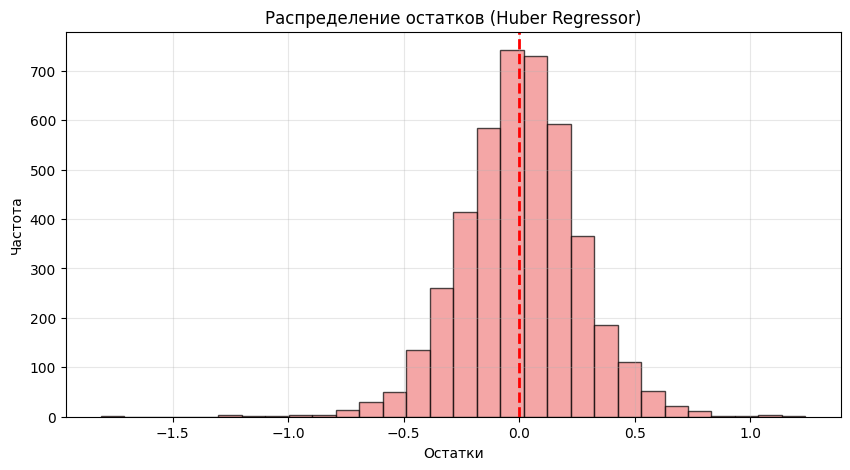


 Топ-5 лучших комбинаций параметров Huber Regressor:
  {'regressor__alpha': 0.01, 'regressor__epsilon': 1.75, 'regressor__max_iter': 1000} | MSE: 0.06 ± 0.00
  {'regressor__alpha': 0.001, 'regressor__epsilon': 1.75, 'regressor__max_iter': 1000} | MSE: 0.06 ± 0.00
  {'regressor__alpha': 0.0001, 'regressor__epsilon': 1.75, 'regressor__max_iter': 1000} | MSE: 0.06 ± 0.00
  {'regressor__alpha': 0.01, 'regressor__epsilon': 1.5, 'regressor__max_iter': 1000} | MSE: 0.06 ± 0.00
  {'regressor__alpha': 0.001, 'regressor__epsilon': 1.5, 'regressor__max_iter': 1000} | MSE: 0.06 ± 0.00


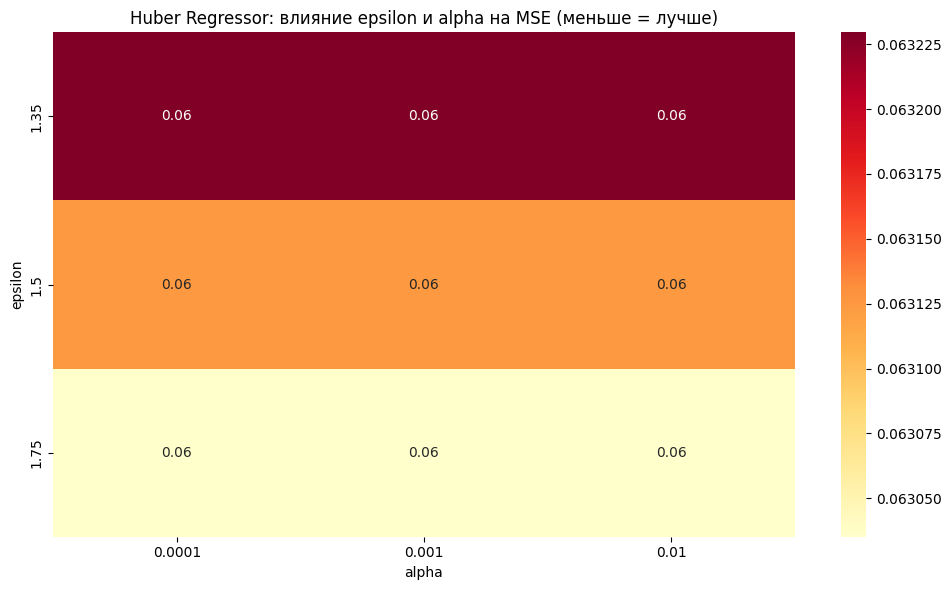


СРАВНЕНИЕ С ОБЫЧНОЙ ЛИНЕЙНОЙ РЕГРЕССИЕЙ
Метрика              Linear Reg      Huber Reg      
--------------------------------------------------
MSE                  0.06            0.06           
R2                   0.7731          0.7723         
 Обычная линейная регрессия работает не хуже - выбросов немного

 Первые 10 коэффициентов модели (после масштабирования):
    Признак  Коэффициент
         id     0.002164
   bedrooms    -0.011860
  bathrooms     0.058374
sqft_living     0.064387
   sqft_lot     0.016880
     floors     0.045022
 waterfront     0.033557
       view     0.048233
  condition     0.038919
      grade     0.182931


In [16]:
# 5. Регрессор Губера (HuberRegressor)
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Проверка качества обученной модели
def evaluate_model(grid_search, X_train, y_train, X_test, y_test, model_name):
    """Простая функция для оценки модели"""
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    y_pred = grid_search.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\nРезультаты для {model_name}:")
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"MSE на тесте: {mse:.2f}")
    print(f"MAE на тесте: {mae:.2f}")
    print(f"R2 на тесте: {r2:.4f}")

    return y_pred

print("\n" + "="*60)
print("HUBER РЕГРЕССОР")
print("="*60)

# ОПРЕДЕЛЯЕМ numeric_features на основе X_train
# Предполагаем, что X_train - это pandas DataFrame
if isinstance(X_train, pd.DataFrame):
    # Берем только числовые колонки
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    print(f"Найдено {len(numeric_features)} числовых признаков")
else:
    # Если X_train - это numpy array, создаем простые имена
    numeric_features = [f"feature_{i}" for i in range(X_train.shape[1])]
    print(f"Создано {len(numeric_features)} признаков")

# Добавляем масштабирование
preprocessor_huber = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

# Пайплайн с препроцессором и HuberRegressor
huber_pipeline = Pipeline(steps=[('preprocessor', preprocessor_huber),
                                  ('regressor', HuberRegressor(max_iter=1000))])

# Сетка параметров для HuberRegressor
param_grid_huber = {
    'regressor__epsilon': [1.35, 1.5, 1.75],        # параметр, контролирующий чувствительность к выбросам
    'regressor__alpha': [0.0001, 0.001, 0.01],      # сила регуляризации
    'regressor__max_iter': [1000]                    # фиксируем максимальное число итераций
}

print(f"Всего комбинаций: 3×3×1 = 9 комбинаций")
print(f"С cv=5 будет: 9×5 = 45 обучений")
print(f"⏱ Примерное время: 1-2 минуты")

# GridSearchCV с 5-кратной кросс-валидацией
grid_huber = GridSearchCV(huber_pipeline, param_grid_huber, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print('Подбор параметров для HuberRegressor с GridSearchCV...')
grid_huber.fit(X_train, y_train)

print(f"\n Лучшие параметры HuberRegressor: {grid_huber.best_params_}")
best_huber = grid_huber.best_estimator_

# Оценка модели и получение предсказаний
y_pred_huber = evaluate_model(grid_huber, X_train, y_train, X_test, y_test, "HuberRegressor")

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_huber, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title('Huber Regressor: Predicted vs Actual')
plt.grid(True, alpha=0.3)

# График остатков
plt.subplot(1, 2, 2)
residuals_huber = y_test - y_pred_huber
plt.scatter(y_pred_huber, residuals_huber, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (Huber Regressor)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Важность признаков (коэффициенты)
feature_names = numeric_features

# Для линейных моделей важность - это абсолютные значения коэффициентов
coefficients = best_huber.named_steps['regressor'].coef_
coef_imp = pd.Series(np.abs(coefficients), index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 0.9, len(coef_imp)))
coef_imp.plot(kind='bar', color=colors)
plt.title('Важность признаков (Huber Regressor) - абсолютные значения коэффициентов')
plt.xlabel('Признаки')
plt.ylabel('|Коэффициент|')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Распределение остатков
plt.figure(figsize=(10, 5))
plt.hist(residuals_huber, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков (Huber Regressor)')
plt.grid(True, alpha=0.3)
plt.show()

# Сравнение результатов GridSearch
results_huber = pd.DataFrame(grid_huber.cv_results_)
top_results_huber = results_huber.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']].copy()
top_results_huber['mean_test_score'] = -top_results_huber['mean_test_score']
top_results_huber = top_results_huber.rename(columns={'mean_test_score': 'MSE'})

print("\n Топ-5 лучших комбинаций параметров Huber Regressor:")
for i, row in top_results_huber.iterrows():
    print(f"  {row['params']} | MSE: {row['MSE']:.2f} ± {row['std_test_score']:.2f}")

# Тепловая карта: epsilon vs alpha
if hasattr(grid_huber, 'cv_results_'):
    pivot_huber = results_huber.pivot_table(
        values='mean_test_score',
        index='param_regressor__epsilon',
        columns='param_regressor__alpha',
        aggfunc='mean'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(-pivot_huber, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=pivot_huber.columns, yticklabels=pivot_huber.index)
    plt.title('Huber Regressor: влияние epsilon и alpha на MSE (меньше = лучше)')
    plt.xlabel('alpha')
    plt.ylabel('epsilon')
    plt.tight_layout()
    plt.show()

# Сравнение с обычной линейной регрессией
from sklearn.linear_model import LinearRegression

# Обучаем простую линейную регрессию для сравнения (тоже с масштабированием!)
lr_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

lr_pipeline = Pipeline(steps=[('preprocessor', lr_preprocessor),
                               ('regressor', LinearRegression())])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_huber = mean_squared_error(y_test, y_pred_huber)
r2_lr = r2_score(y_test, y_pred_lr)
r2_huber = r2_score(y_test, y_pred_huber)

print("\n" + "="*60)
print("СРАВНЕНИЕ С ОБЫЧНОЙ ЛИНЕЙНОЙ РЕГРЕССИЕЙ")
print("="*60)
print(f"{'Метрика':<20} {'Linear Reg':<15} {'Huber Reg':<15}")
print("-"*50)
print(f"{'MSE':<20} {mse_lr:<15.2f} {mse_huber:<15.2f}")
print(f"{'R2':<20} {r2_lr:<15.4f} {r2_huber:<15.4f}")
print("="*60)

if mse_huber < mse_lr:
    print(" HuberRegressor работает лучше - в данных есть выбросы!")
else:
    print(" Обычная линейная регрессия работает не хуже - выбросов немного")

# Выведем коэффициенты
print("\n Первые 10 коэффициентов модели (после масштабирования):")
coef_df = pd.DataFrame({
    'Признак': feature_names[:10],
    'Коэффициент': coefficients[:10]
})
print(coef_df.to_string(index=False))


СРАВНЕНИЕ 5 МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ
  CatBoost            : MAE=0.11, RMSE=0.16, R2=0.9127
  Gradient Boosting   : MAE=0.12, RMSE=0.16, R2=0.9078
  Random Forest       : MAE=0.13, RMSE=0.18, R2=0.8906
  XGBoost             : MAE=0.11, RMSE=0.16, R2=0.9099
  Huber Regressor     : MAE=0.19, RMSE=0.25, R2=0.7723


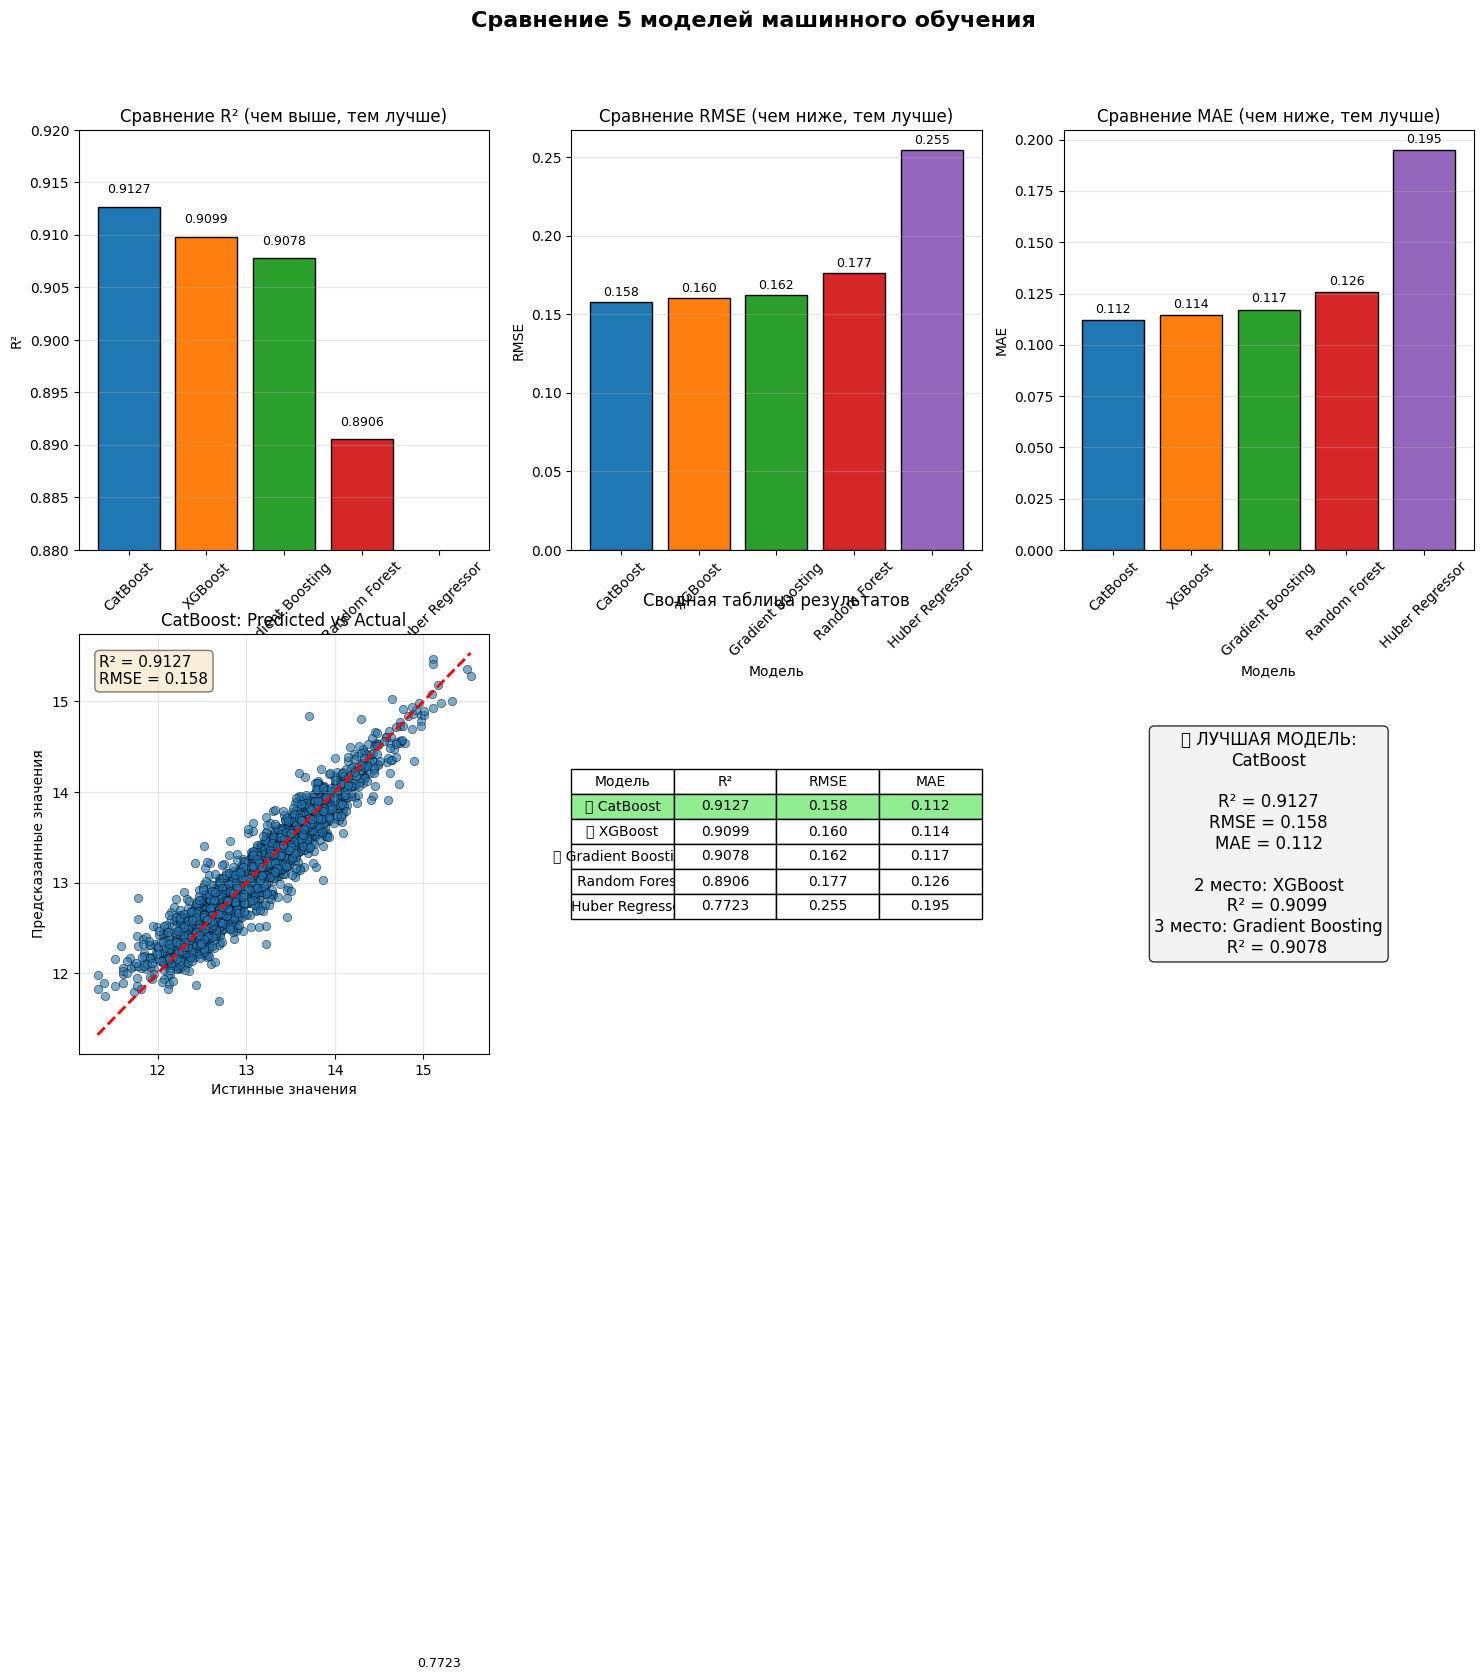


ЛУЧШАЯ МОДЕЛЬ
   🏆 CatBoost
      R²   = 0.9127
      RMSE = 0.158
      MAE  = 0.112

📊 Рейтинг моделей:
------------------------------------------------------------
Место    Модель               R²         RMSE       MAE       
------------------------------------------------------------
1 место 🥇 CatBoost             0.9127     0.158      0.112     
2 место 🥈 XGBoost              0.9099     0.160      0.114     
3 место 🥉 Gradient Boosting    0.9078     0.162      0.117     
4 место  Random Forest        0.8906     0.177      0.126     
5 место  Huber Regressor      0.7723     0.255      0.195     

💾 Результаты сохранены в 'model_comparison_5_models.csv'


In [17]:

# СРАВНЕНИЕ 5 МОДЕЛЕЙ (Включая Huber)
# ============================================
# СРАВНЕНИЕ 5 МОДЕЛЕЙ И ВЫБОР ЛУЧШЕЙ
# (CatBoost, Gradient Boosting, Random Forest, XGBoost, Huber)
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Список для результатов
results = []

# Функция для добавления результатов
def add_result(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"  {name:20s}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

print("\n" + "="*70)
print("СРАВНЕНИЕ 5 МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*70)

# Добавляем результаты всех 5 моделей
models_to_check = [
    ('CatBoost', 'y_pred_cb'),
    ('Gradient Boosting', 'y_pred_gb'),
    ('Random Forest', 'y_pred_rf'),
    ('XGBoost', 'y_pred_xgb'),
    ('Huber Regressor', 'y_pred_huber')
]

for name, var_name in models_to_check:
    try:
        y_pred = eval(var_name)
        add_result(name, y_test, y_pred)
    except NameError:
        print(f"  ✗ {name:20s} не найдена")

# Создаем DataFrame и сортируем по R²
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

# ============================================
# ВИЗУАЛИЗАЦИЯ
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Сравнение 5 моделей машинного обучения', fontsize=16, fontweight='bold')

# Цвета для моделей
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. Сравнение R²
ax = axes[0, 0]
bars = ax.bar(results_df['Model'], results_df['R2'], color=colors[:len(results_df)], edgecolor='black')
ax.set_xlabel('Модель')
ax.set_ylabel('R²')
ax.set_title('Сравнение R² (чем выше, тем лучше)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.88, 0.92)
for bar, val in zip(bars, results_df['R2']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# 2. Сравнение RMSE
ax = axes[0, 1]
bars = ax.bar(results_df['Model'], results_df['RMSE'], color=colors[:len(results_df)], edgecolor='black')
ax.set_xlabel('Модель')
ax.set_ylabel('RMSE')
ax.set_title('Сравнение RMSE (чем ниже, тем лучше)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, results_df['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 3. Сравнение MAE
ax = axes[0, 2]
bars = ax.bar(results_df['Model'], results_df['MAE'], color=colors[:len(results_df)], edgecolor='black')
ax.set_xlabel('Модель')
ax.set_ylabel('MAE')
ax.set_title('Сравнение MAE (чем ниже, тем лучше)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, results_df['MAE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 4. Лучшая модель - Predicted vs Actual
best_model = results_df.iloc[0]['Model']
best_pred = None
for name, var_name in models_to_check:
    if name == best_model:
        try:
            best_pred = eval(var_name)
        except NameError:
            pass

ax = axes[1, 0]
if best_pred is not None:
    ax.scatter(y_test, best_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Истинные значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{best_model}: Predicted vs Actual')
    ax.grid(True, alpha=0.3)

    # Добавляем метрики на график
    r2 = results_df.iloc[0]['R2']
    rmse = results_df.iloc[0]['RMSE']
    ax.text(0.05, 0.95, f'R² = {r2:.4f}\nRMSE = {rmse:.3f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 5. Таблица результатов
ax = axes[1, 1]
ax.axis('off')
ax.axis('tight')

# Создаем таблицу
table_data = []
for i, row in results_df.iterrows():
    medal = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else "  "
    table_data.append([f"{medal} {row['Model']}", f"{row['R2']:.4f}", f"{row['RMSE']:.3f}", f"{row['MAE']:.3f}"])

table = ax.table(cellText=table_data,
                 colLabels=['Модель', 'R²', 'RMSE', 'MAE'],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Выделяем лучшую строку
for j in range(4):
    table[(1, j)].set_facecolor('#90EE90')  # светло-зеленый

ax.set_title('Сводная таблица результатов', fontsize=12, pad=20)

# 6. Дополнительный график: Сравнение всех метрик
ax = axes[1, 2]
ax.axis('off')

# Создаем текстовое резюме
text = f"🏆 ЛУЧШАЯ МОДЕЛЬ:\n"
text += f"{results_df.iloc[0]['Model']}\n\n"
text += f"R² = {results_df.iloc[0]['R2']:.4f}\n"
text += f"RMSE = {results_df.iloc[0]['RMSE']:.3f}\n"
text += f"MAE = {results_df.iloc[0]['MAE']:.3f}\n\n"

if len(results_df) > 1:
    text += f"2 место: {results_df.iloc[1]['Model']}\n"
    text += f"   R² = {results_df.iloc[1]['R2']:.4f}\n"
if len(results_df) > 2:
    text += f"3 место: {results_df.iloc[2]['Model']}\n"
    text += f"   R² = {results_df.iloc[2]['R2']:.4f}"

ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=12,
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================
# ВЫВОД
# ============================================
print("\n" + "="*70)
print("ЛУЧШАЯ МОДЕЛЬ")
print("="*70)
best = results_df.iloc[0]
print(f"   🏆 {best['Model']}")
print(f"      R²   = {best['R2']:.4f}")
print(f"      RMSE = {best['RMSE']:.3f}")
print(f"      MAE  = {best['MAE']:.3f}")

# Рейтинг моделей
print("\n📊 Рейтинг моделей:")
print("-" * 60)
print(f"{'Место':<8} {'Модель':<20} {'R²':<10} {'RMSE':<10} {'MAE':<10}")
print("-" * 60)

medals = ['1 место 🥇', '2 место 🥈', '3 место 🥉', '4 место', '5 место']
for i, row in results_df.iterrows():
    medal = medals[i] if i < len(medals) else f'{i+1} место'
    print(f"{medal:<8} {row['Model']:<20} {row['R2']:<10.4f} {row['RMSE']:<10.3f} {row['MAE']:<10.3f}")

# ============================================
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
# Сохраняем результаты в CSV
results_df.to_csv('model_comparison_5_models.csv', index=False)
print("\n💾 Результаты сохранены в 'model_comparison_5_models.csv'")